### EXAPLE PAG 88 CIGRE 601 2014: Transient temperature calculation

In [1]:
%load_ext autoreload
%matplotlib widget
%autoreload 2
from   data_models.test_SS_models import get_models_test_SS
from   data_models.test_SS_data   import get_data_test_SS
import matplotlib.pyplot as plt
import numpy as np

In [2]:

dt_data   = 10    # weather data sampling                  (min)
dt_interp = 60    # interpolation for integration sampling (secs)
t_data    = np.arange(3)*dt_data*60  # (s)

Ta = np.array([23.7,23.5,23.5])
Ws = np.array([1.7,0.8,0.8])
Wd = np.array([62,37,37])
IT = np.zeros_like(Wd)
I  = np.array([819,856,856])

# generate the models 
MODE = 0
data = get_data_test_SS(MODE=MODE)
model_cigre, model_ieee = get_models_test_SS(data)

model_cigre.conditions.mode_solar_radiation_data = True   
model_cigre.conditions.global_solar_radiation    = 0

# only for knowing the heat balance for the initial conditions not necessary for comuting the transient
print_balance = False
I_1 = model_cigre.SS_Thermal_Rating(print_out=print_balance);
T_1 = model_cigre.SS_Conductor_Temperature(print_out=print_balance);

# transient temperature tracking calculation
print('E3 TRANSIENT TEMPERATURE TRACKING CALCULATION STEPS')
print('*'*50)

model_cigre.conditions.conductor_temperature = 42.01
t_tran, T_tran, data_tran = model_cigre.TRAN_Conductor_Temperature(t_data, Ws, Wd, Ta, I, IT, dt_tran=dt_interp, mode="Step", print_out=True);


E3 TRANSIENT TEMPERATURE TRACKING CALCULATION STEPS
**************************************************
 1     0.1645    42.1745
 2     0.1451    42.3195
 3     0.1279    42.4475
 4     0.1128    42.5603
 5     0.0995    42.6598
 6     0.0877    42.7475
 7     0.0774    42.8249
 8     0.0682    42.8931
 9     0.0602    42.9533
10     0.0531    43.0064
 1     1.1356    44.1420
 2     1.0512    45.1932
 3     0.9729    46.1661
 4     0.9002    47.0663
 5     0.8328    47.8991
 6     0.7704    48.6695
 7     0.7124    49.3819
 8     0.6588    50.0407
 9     0.6091    50.6498
10     0.5631    51.2129


Text(0, 0.5, 'Conductor Temperature (°C)')

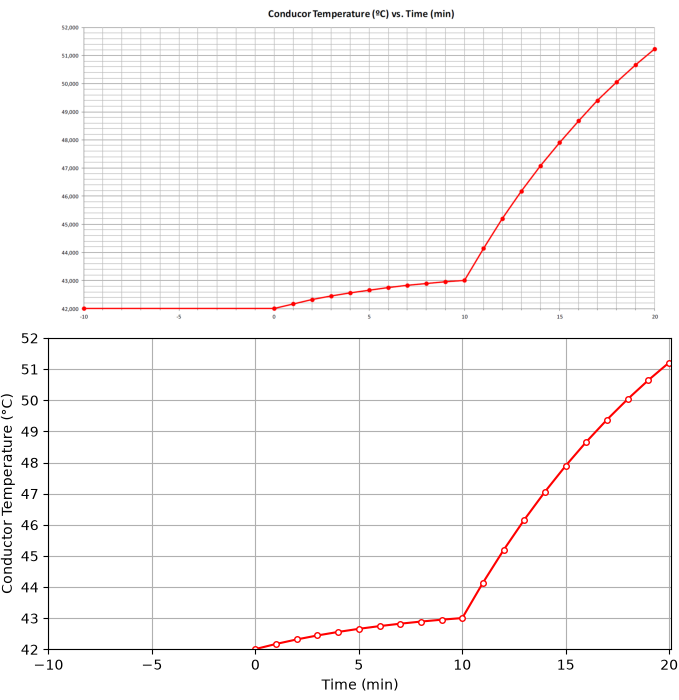

In [3]:
s        = 7
ar       = 0.97
fig, ax  = plt.subplots(2,1,constrained_layout=True,figsize=(ar*s,s))

ax[0].imshow( plt.imread('./imgs/tran_cigre.png') )
ax[0].axis('off')

ax[1].plot(t_tran/60, T_tran,'ro-',ms=4,mfc='w')
ax[1].set_xlim(-10,20.1);ax[1].set_ylim(42,52)
ax[1].set_yticks(np.arange(42,53));
ax[1].set_box_aspect(1/2)
ax[1].grid()
ax[1].set_xlabel('Time (min)')
ax[1].set_ylabel('Conductor Temperature (°C)')